librerias

In [2]:
# utilizado para la manipulación de directorios y rutas
import os

# Cálculo científico y vectorial para python
import numpy as np

# Manejo de datos
import pandas as pd

# Librería para gráficos
from matplotlib import pyplot

# Optimización
from scipy import optimize

# le dice a matplotlib que incruste gráficos en el cuaderno
%matplotlib inline

cargar dataset

In [3]:
# Cargar el dataset EMNIST Balanced

ruta = "dataset_5/emnist-balanced-train.csv"

datos = pd.read_csv(ruta, header=None)

print("Forma del dataset:", datos.shape)
print(datos.head())

Forma del dataset: (112800, 785)
   0    1    2    3    4    5    6    7    8    9    ...  775  776  777  778  \
0   45    0    0    0    0    0    0    0    0    0  ...    0    0    0    0   
1   36    0    0    0    0    0    0    0    0    0  ...    0    0    0    0   
2   43    0    0    0    0    0    0    0    0    0  ...    0    0    0    0   
3   15    0    0    0    0    0    0    0    0    0  ...    0    0    0    0   
4    4    0    0    0    0    0    0    0    0    0  ...    0    0    0    0   

   779  780  781  782  783  784  
0    0    0    0    0    0    0  
1    0    0    0    0    0    0  
2    0    0    0    0    0    0  
3    0    0    0    0    0    0  
4    0    0    0    0    0    0  

[5 rows x 785 columns]


In [5]:
# Separar etiquetas y características

y = datos.iloc[:, 0].to_numpy()
X = datos.iloc[:, 1:].to_numpy()

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

Forma de X: (112800, 784)
Forma de y: (112800,)


In [ ]:

input_layer_size = 784


num_labels = 47

# Número de ejemplos
m = y.size

print("Tamaño de entrada:", input_layer_size)
print("Número de clases:", num_labels)
print("Número de ejemplos:", m)

Tamaño de entrada: 784
Número de clases: 47
Número de ejemplos: 112800


In [7]:
print("Clases presentes:")
print(np.unique(y))

print("\nCantidad de clases:", len(np.unique(y)))

Clases presentes:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46]

Cantidad de clases: 47


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (90240, 784)
y_train: (90240,)
X_test: (22560, 784)
y_test: (22560,)


In [18]:
print("Valor mínimo:", X.min())
print("Valor máximo:", X.max())

print("Valores únicos (primeros 20):")
print(np.unique(X)[:20])

Valor mínimo: 0
Valor máximo: 255
Valores únicos (primeros 20):
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]


In [20]:
print("Primeros 30 píxeles de la primera imagen:")
print(X[0, :400])

Primeros 30 píxeles de la primera imagen:
[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   1   7  32  36  21   3   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   8  33 113 124  81  22   7   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   2  77 158 243 249 232 159  95
  34  20   1   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   4 124 213 254 254 254 247 234 202 154  23   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   4 114 203 254 254 254
 254 252 242 207  59   7   1   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0  45 122 230 245 252 254 254 254 249 207  91  36   4
   2   0   0   0   0   0   0   0   0   0   0   0   0   0   0  20  67 170
 204 236 

normalizar pixeles

In [21]:
X_train = X_train.astype(np.float64) / 255.0
X_test = X_test.astype(np.float64) / 255.0

In [22]:
print("Mínimo X_train:", X_train.min())
print("Máximo X_train:", X_train.max())

print("Mínimo X_test:", X_test.min())
print("Máximo X_test:", X_test.max())

Mínimo X_train: 0.0
Máximo X_train: 1.0
Mínimo X_test: 0.0
Máximo X_test: 1.0


In [16]:
def displayData(X, example_width=None, figsize=(10, 10)):
    """
    Muestra datos 2D almacenados en X en una cuadrícula apropiada.
    """
    # Calcula filas, columnas
    if X.ndim == 2:
        m, n = X.shape
    elif X.ndim == 1:
        n = X.size
        m = 1
        X = X[None]  # Promocionar a una matriz bidimensional
    else:
        raise IndexError('La entrada X debe ser 1 o 2 dimensinal.')

    example_width = example_width or int(np.round(np.sqrt(n)))
    example_height = n / example_width

    # Calcula el numero de elementos a mostrar
    display_rows = int(np.floor(np.sqrt(m)))
    display_cols = int(np.ceil(m / display_rows))

    fig, ax_array = pyplot.subplots(display_rows, display_cols, figsize=figsize)
    fig.subplots_adjust(wspace=0.025, hspace=0.025)

    ax_array = [ax_array] if m == 1 else ax_array.ravel()

    for i, ax in enumerate(ax_array):
        ax.imshow(X[i].reshape(example_width, example_width, order='F'),
                  cmap='Greys', extent=[0, 1, 0, 1])
        ax.axis('off')

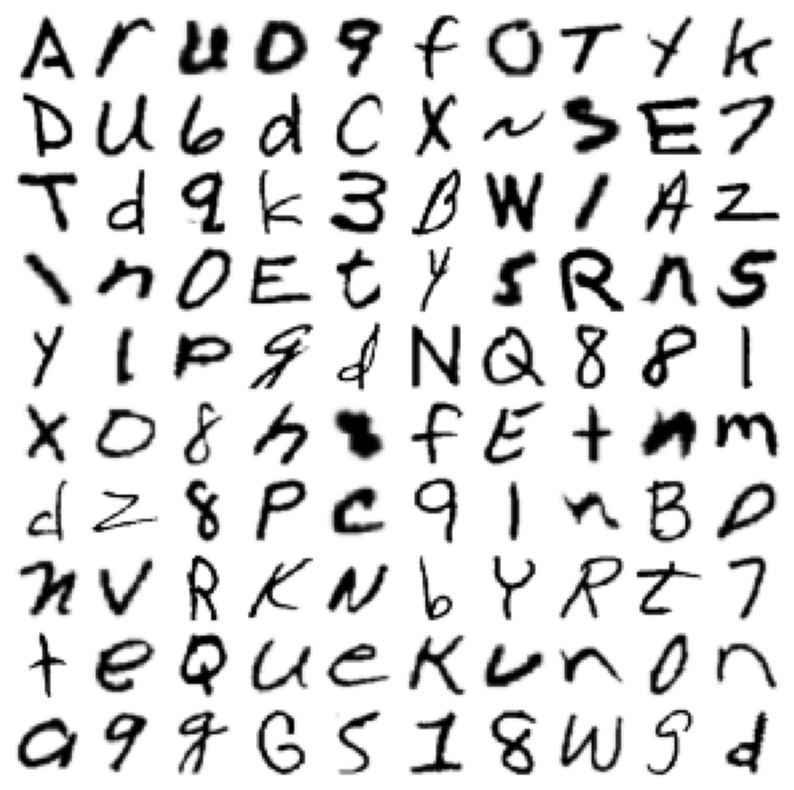

In [17]:
# Selecciona aleatoriamente 100 puntos de datos para mostrar
rand_indices = np.random.choice(m, 100, replace=False)
sel = X[rand_indices, :]

displayData(sel)

funcion sigmoID

In [23]:
def sigmoid(z):
    """
    Calcula la sigmoide de z.
    """
    return 1.0 / (1.0 + np.exp(-z))

vectorizacion de la funcion de costo

In [24]:
def lrCostFunction(theta, X, y, lambda_):
    """
    Calcula el costo y el gradiente de la regresión logística
    regularizada.
    """

    m = y.size

    if y.dtype == bool:
        y = y.astype(int)

    h = sigmoid(X.dot(theta.T))

    # Copia de theta para no regularizar theta_0
    temp = theta.copy()
    temp[0] = 0

    # Costo
    J = (
        (1 / m) * np.sum(
            -y.dot(np.log(h)) -
            (1 - y).dot(np.log(1 - h))
        )
        + (lambda_ / (2 * m)) * np.sum(np.square(temp))
    )

    # Gradiente
    grad = (1 / m) * (h - y).dot(X)
    grad = grad + (lambda_ / m) * temp

    return J, grad

clasificacion one vs all

In [26]:
def oneVsAll(X, y, num_labels, lambda_):
    
    m, n = X.shape

    # Una fila por clase y un theta por cada característica + intercepto
    all_theta = np.zeros((num_labels, n + 1))

    # Agregar término de intersección
    X = np.concatenate(
        [np.ones((m, 1)), X],
        axis=1
    )

    for c in np.arange(num_labels):

        print("Entrenando clase", c)

        initial_theta = np.zeros(n + 1)

        options = {'maxiter': 50}

        res = optimize.minimize(
            lrCostFunction,
            initial_theta,
            (X, (y == c), lambda_),
            jac=True,
            method='CG',
            options=options
        )

        all_theta[c] = res.x

    return all_theta

In [27]:
lambda_ = 0.1

all_theta = oneVsAll(
    X_train,
    y_train,
    num_labels,
    lambda_
)

print("Forma de all_theta:", all_theta.shape)

Entrenando clase 0
Entrenando clase 1
Entrenando clase 2
Entrenando clase 3
Entrenando clase 4
Entrenando clase 5
Entrenando clase 6
Entrenando clase 7
Entrenando clase 8
Entrenando clase 9
Entrenando clase 10
Entrenando clase 11
Entrenando clase 12
Entrenando clase 13
Entrenando clase 14
Entrenando clase 15
Entrenando clase 16
Entrenando clase 17
Entrenando clase 18
Entrenando clase 19
Entrenando clase 20
Entrenando clase 21
Entrenando clase 22
Entrenando clase 23
Entrenando clase 24
Entrenando clase 25
Entrenando clase 26
Entrenando clase 27
Entrenando clase 28
Entrenando clase 29
Entrenando clase 30
Entrenando clase 31
Entrenando clase 32
Entrenando clase 33
Entrenando clase 34
Entrenando clase 35
Entrenando clase 36
Entrenando clase 37
Entrenando clase 38
Entrenando clase 39
Entrenando clase 40
Entrenando clase 41
Entrenando clase 42
Entrenando clase 43
Entrenando clase 44
Entrenando clase 45
Entrenando clase 46
Forma de all_theta: (47, 785)


prediccion one vs all

In [28]:
def predictOneVsAll(all_theta, X):

    m = X.shape[0]

    # Agregar término de intersección
    X = np.concatenate(
        [np.ones((m, 1)), X],
        axis=1
    )

    # Calcular probabilidades para las 47 clases
    probabilidades = sigmoid(X.dot(all_theta.T))

    # Seleccionar la clase con mayor probabilidad
    p = np.argmax(probabilidades, axis=1)

    return p

In [29]:
pred_train = predictOneVsAll(
    all_theta,
    X_train
)

precision_train = np.mean(
    pred_train == y_train
) * 100

print(
    "Precisión en entrenamiento: {:.2f}%".format(
        precision_train
    )
)

Precisión en entrenamiento: 70.50%


In [30]:
pred_test = predictOneVsAll(
    all_theta,
    X_test
)

precision_test = np.mean(
    pred_test == y_test
) * 100

print(
    "Precisión en prueba: {:.2f}%".format(
        precision_test
    )
)

Precisión en prueba: 67.86%


In [31]:
# Seleccionar 12 ejemplos del conjunto de prueba
indices = np.arange(12)

print("Predicciones sobre ejemplos del conjunto de prueba")
print("=" * 60)

for i in indices:
    print(
        f"Ejemplo {i+1:2d} | "
        f"Clase real: {y_test[i]:2d} | "
        f"Clase predicha: {pred_test[i]:2d} | "
        f"{'CORRECTA' if y_test[i] == pred_test[i] else 'INCORRECTA'}"
    )

Predicciones sobre ejemplos del conjunto de prueba
Ejemplo  1 | Clase real:  9 | Clase predicha:  9 | CORRECTA
Ejemplo  2 | Clase real: 32 | Clase predicha: 32 | CORRECTA
Ejemplo  3 | Clase real: 17 | Clase predicha: 17 | CORRECTA
Ejemplo  4 | Clase real:  5 | Clase predicha:  5 | CORRECTA
Ejemplo  5 | Clase real:  4 | Clase predicha: 43 | INCORRECTA
Ejemplo  6 | Clase real:  7 | Clase predicha:  7 | CORRECTA
Ejemplo  7 | Clase real: 36 | Clase predicha: 10 | INCORRECTA
Ejemplo  8 | Clase real:  2 | Clase predicha: 35 | INCORRECTA
Ejemplo  9 | Clase real:  0 | Clase predicha:  0 | CORRECTA
Ejemplo 10 | Clase real: 22 | Clase predicha: 22 | CORRECTA
Ejemplo 11 | Clase real: 18 | Clase predicha:  1 | INCORRECTA
Ejemplo 12 | Clase real: 26 | Clase predicha: 26 | CORRECTA


visualizacion

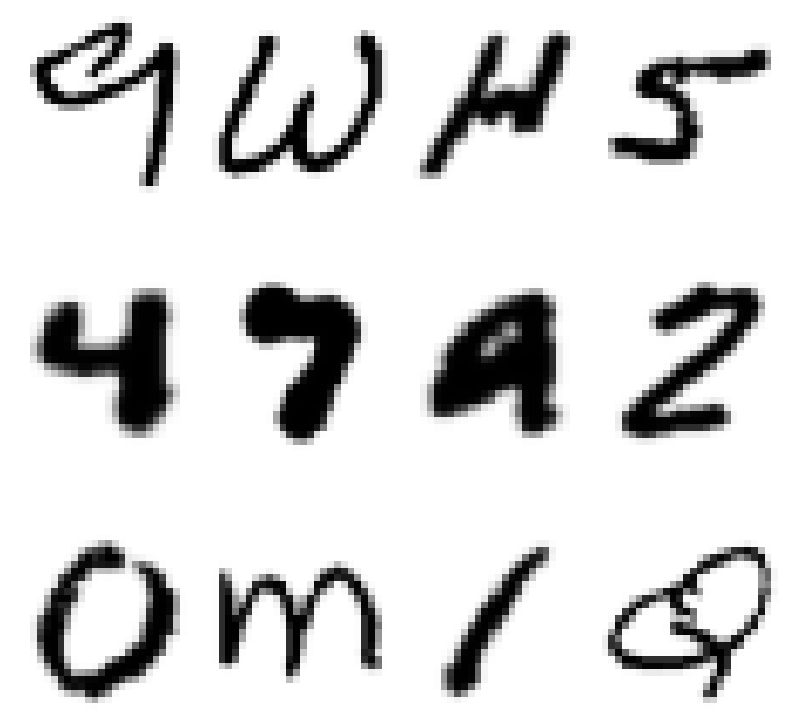

In [32]:
displayData(X_test[:12, :])